In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Partie 0

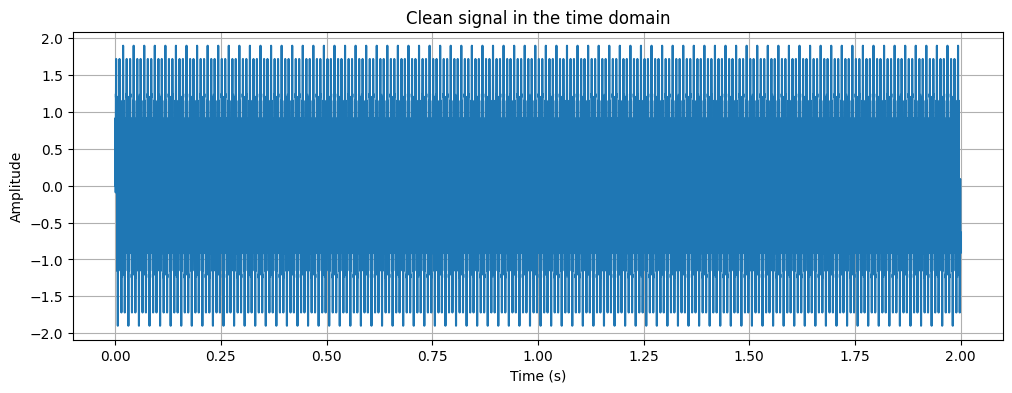

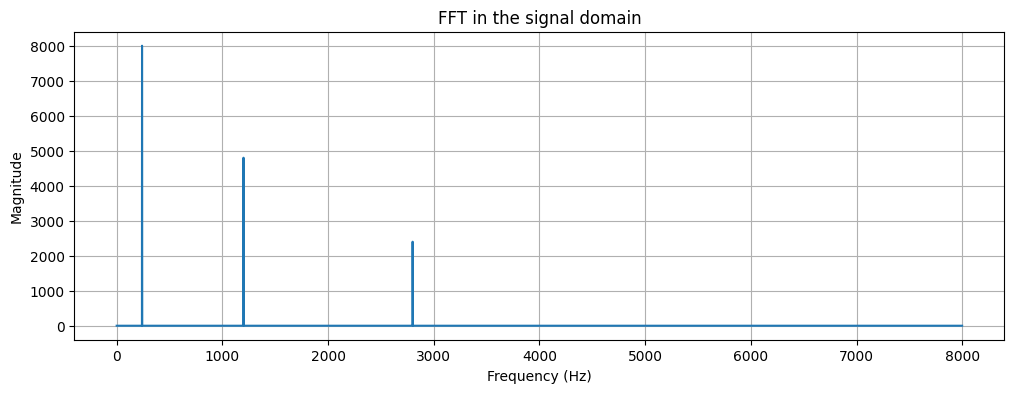

In [3]:
fs = 8000
T = 2

t = np.arange(0, T, 1/fs)  # Time vector from 0 to 1 second

# Sinusoidal signals with different frequencies and amplitudes
f1, f2, f3 = 120, 600, 1400  # Frequencies in Hz
A1, A2, A3 = 1.0, 0.6, 0.3  # Amplitudes

# Composite signal
signal = A1 * np.sin(2 * np.pi * f1 * t) + \
         A2 * np.sin(2 * np.pi * f2 * t) + \
         A3 * np.sin(2 * np.pi * f3 * t)

# Plot the time domain signal
plt.figure(figsize=(12, 4))
plt.plot(t, signal)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Clean signal in the time domain")
plt.grid()
plt.show()


fft_coeffs = abs(np.fft.fft(signal))
frequencies = range(len(signal))

plt.figure(figsize=(12, 4))
plt.plot(frequencies[:len(frequencies)//2], np.abs(fft_coeffs)[:len(frequencies)//2], label="FFT Magnitude")
# plt.plot(frequencies, fft_coefs)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT in the signal domain")
plt.grid()
plt.show()

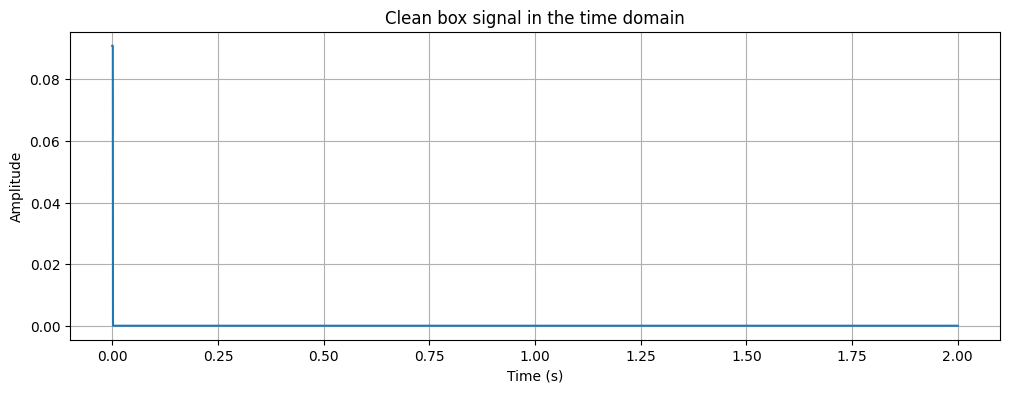

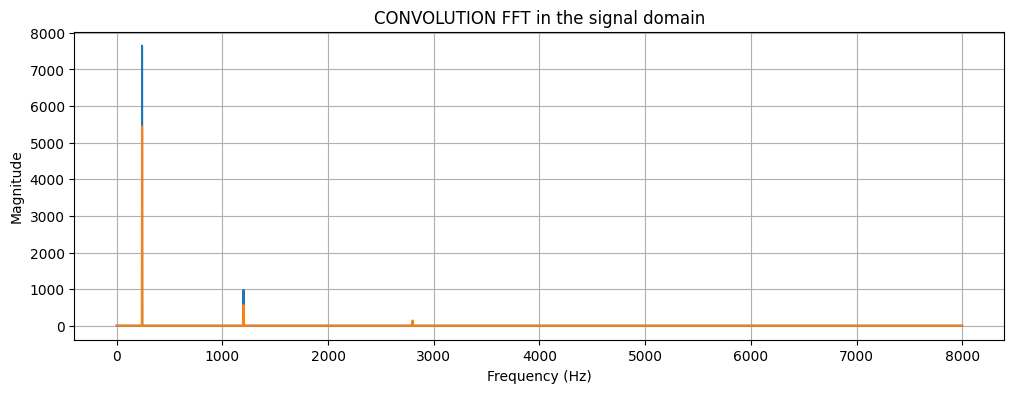

In [4]:
S = 11
sliding_average = [1/S if(i >= 0 and i <= S-1) else 0 for i in range(len(signal))]
plt.figure(figsize=(12, 4))
plt.plot(t, sliding_average)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Clean box signal in the time domain")
plt.grid()
plt.show()

sliding_fft_coeffs = np.fft.fft(sliding_average)
convulution = fft_coeffs*sliding_fft_coeffs
plt.figure(figsize=(12, 4))
plt.plot(frequencies[:len(frequencies)//2], np.abs(convulution)[:len(frequencies)//2], label="FFT Magnitude")

S = 31
sliding_average = [1/S if(i >= 0 and i <= S-1) else 0 for i in range(len(signal))]
sliding_fft_coeffs = np.fft.fft(sliding_average)
convulution = fft_coeffs*sliding_fft_coeffs

plt.plot(frequencies[:len(frequencies)//2], np.abs(convulution)[:len(frequencies)//2], label="FFT Magnitude")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("CONVOLUTION FFT in the signal domain")
plt.grid()
plt.show()

In [11]:
# plt.specgram(fft_coeffs)
# plt.show()